# Access 4DMED-SEA 3D Physical Fields
    * Original Data Source:https://zenodo.org/records/13969340
    * Reference:  https://zenodo.org/records/13969340
    * OSC entry: https://opensciencedata.esa.int/products/4dmed-t-s-geo-150/collection
    * License: CC-BY-4.0

In [4]:
import xarray as xr 

zarr_href = 'https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/ocean_datasets/tsgeo150.zarr/'

In [5]:
ds = xr.open_zarr(zarr_href)
ds

<xarray.Dataset> Size: 740GB
Dimensions:    (time: 2404, latitude: 377, longitude: 1010, depth: 20)
Coordinates:
  * time       (time) datetime64[ns] 19kB 2016-01-01T12:00:00 ... 2022-07-31T...
  * latitude   (latitude) float32 2kB 30.27 30.31 30.35 ... 45.85 45.9 45.94
  * longitude  (longitude) float32 4kB -5.979 -5.937 -5.896 ... 36.02 36.06
  * depth      (depth) int16 40B 1 3 5 7 10 13 16 ... 66 78 91 104 119 135 153
Data variables:
    mlotst     (time, latitude, longitude) float64 7GB dask.array<chunksize=(7, 377, 1010), meta=np.ndarray>
    so         (time, depth, latitude, longitude) float64 146GB dask.array<chunksize=(7, 20, 377, 1010), meta=np.ndarray>
    to         (time, depth, latitude, longitude) float64 146GB dask.array<chunksize=(7, 20, 377, 1010), meta=np.ndarray>
    ugo        (time, depth, latitude, longitude) float64 146GB dask.array<chunksize=(7, 20, 377, 1010), meta=np.ndarray>
    vgo        (time, depth, latitude, longitude) float64 146GB dask.array<chunksize=(7, 20, 377, 1010), meta=np.ndarray>
    zo         (time, depth, latitude, longitude) float64 146GB dask.array<chunksize=(7, 20, 377, 1010), meta=np.ndarray>
Attributes:
    description:  ARMOR3D REP CMEMS November 2023 Release
    title:        ARMOR3D REP - TSHUVMld Global Ocean Observation-based Product
    Conventions:  CF-1.0
    institution:  CLS
    domain_name:  GLO
    history:      2022-07-29 00:00:00 ARMOR3D REP - TSHUV Global Ocean Observ...

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# -----------------------------
# Settings
# -----------------------------
date = "2020-06-15"

depths = [10, 50, 100]  

salinity = ds["so"].sel(
    time=date,
    method="nearest"
)

# Select nearest available depths
salinity_depths = [
    salinity.sel(depth=d, method="nearest")
    for d in depths
]

# Load only these three 2-D slices into memory
salinity_depths = [x.compute() for x in salinity_depths]

# Actual date selected
actual_date = np.datetime_as_string(
    salinity_depths[0].time.values,
    unit="D"
)

# Using the same scale makes the depths directly comparable
vmin = min(float(x.min(skipna=True)) for x in salinity_depths)
vmax = max(float(x.max(skipna=True)) for x in salinity_depths)


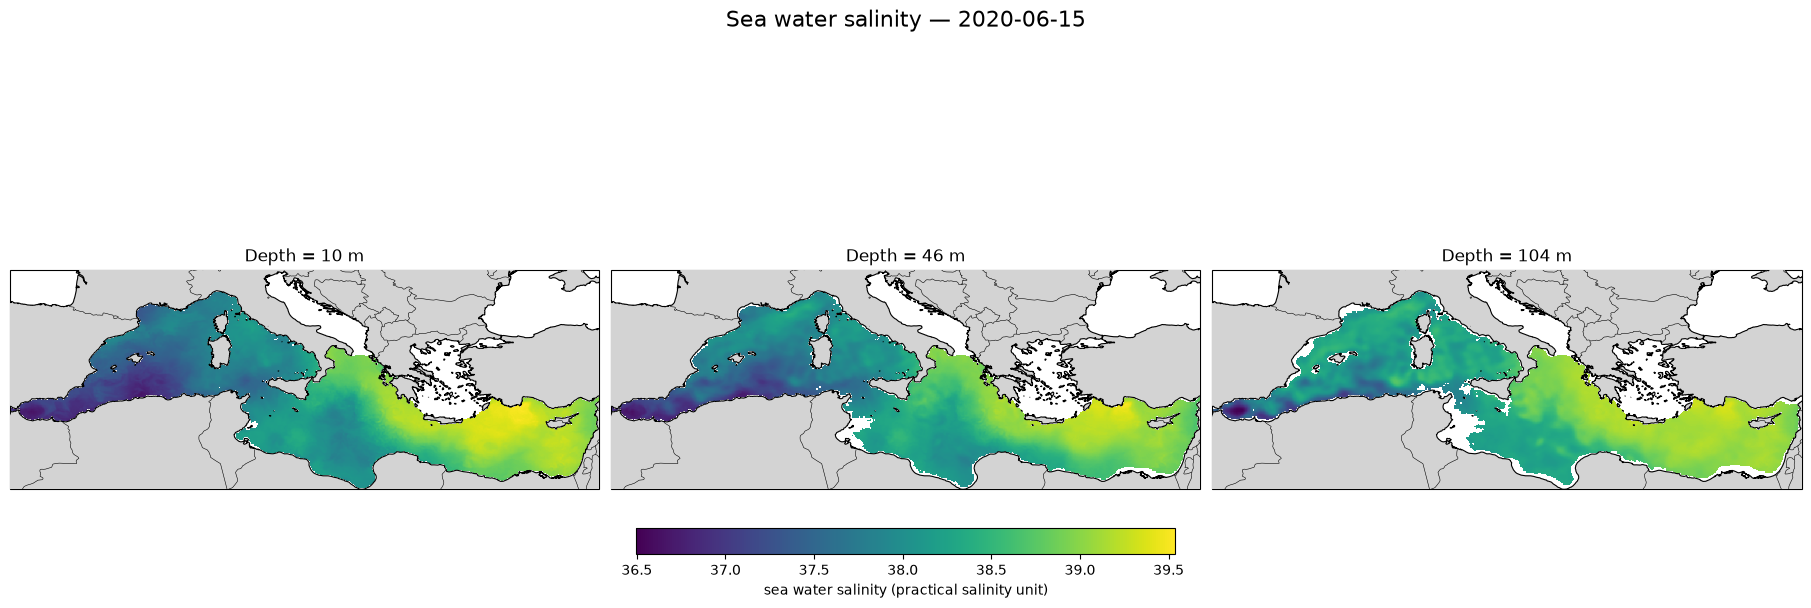

In [13]:


fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

for ax, data, requested_depth in zip(
    axes,
    salinity_depths,
    depths
):
    actual_depth = float(data.depth.values)

    pcm = ax.pcolormesh(
        ds["longitude"],
        ds["latitude"],
        data,
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax
    )

    # Basemap
    ax.add_feature(
        cfeature.LAND,
        facecolor="lightgray",
        zorder=10
    )

    ax.coastlines(
        resolution="10m",
        linewidth=0.8,
        zorder=11
    )

    ax.add_feature(
        cfeature.BORDERS,
        linewidth=0.4,
        zorder=11
    )

    # Mediterranean extent from dataset
    ax.set_extent(
        [
            float(ds.longitude.min()),
            float(ds.longitude.max()),
            float(ds.latitude.min()),
            float(ds.latitude.max())
        ],
        crs=ccrs.PlateCarree()
    )
    
    ax.set_title(
        f"Depth = {abs(actual_depth):.0f} m"
    )

cbar = fig.colorbar(
    pcm,
    ax=axes,
    orientation="horizontal",
    fraction=0.06,
    pad=0.08
)

cbar.set_label(
    r"sea water salinity (practical salinity unit)"
)

fig.suptitle(
    f"Sea water salinity - {actual_date}",
    fontsize=16
)

plt.show()